# Vẽ biểu đồ Loss theo từng Epoch trong Linear Regression

Notebook này giúp bạn hiểu cách **Linear Regression học bằng Gradient Descent** và cách vẽ biểu đồ **loss giảm theo từng epoch**.

---

## 1. Mục tiêu bài học

Sau bài này, bạn sẽ biết:

- Linear Regression dự đoán như thế nào
- Loss Function đo sai số ra sao
- Epoch là gì
- Gradient Descent cập nhật tham số như thế nào
- Cách lưu loss theo từng epoch
- Cách vẽ biểu đồ loss bằng Matplotlib


## 2. Linear Regression là gì?

Linear Regression là mô hình dùng để dự đoán giá trị liên tục.

Ví dụ:

- Dự đoán điểm thi
- Dự đoán giá nhà
- Dự đoán doanh thu

Công thức đơn giản:

```text
y_pred = w * X + b
```

Trong đó:

- `X`: dữ liệu đầu vào
- `y_pred`: giá trị model dự đoán
- `w`: trọng số / weight
- `b`: bias / intercept


## 3. Loss Function là gì?

Loss Function dùng để đo model dự đoán sai bao nhiêu so với giá trị thật.

Trong Linear Regression, ta thường dùng **MSE - Mean Squared Error**.

Công thức:

```text
MSE = (1/n) * sum((y_true - y_pred)^2)
```

Ý nghĩa:

- Loss càng lớn: model dự đoán càng sai
- Loss càng nhỏ: model dự đoán càng tốt
- Trong quá trình học, ta mong muốn loss giảm dần qua từng epoch


## 4. Epoch là gì?

Một **epoch** nghĩa là model đã học qua toàn bộ dataset một lần.

Ví dụ dataset có 100 dòng:

- 1 epoch: model học hết 100 dòng một lần
- 100 epochs: model học lặp lại toàn bộ dataset 100 lần

Sau mỗi epoch, ta tính loss và lưu lại để xem model có học tốt không.


## 5. Import thư viện


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 6. Tạo dữ liệu giả

Ta tạo dữ liệu theo công thức gần đúng:

```text
y = 4 + 3X + noise
```

Nghĩa là giá trị thật gần giống một đường thẳng có:

- bias thật gần bằng 4
- weight thật gần bằng 3
- có thêm noise để dữ liệu giống thực tế hơn


In [2]:
np.random.seed(42)

# Tạo 100 điểm dữ liệu X từ 0 đến 2
X = 2 * np.random.rand(100, 1)

# y = 4 + 3X + noise
y = 4 + 3 * X + np.random.randn(100, 1)

print('Shape X:', X.shape)
print('Shape y:', y.shape)

Shape X: (100, 1)
Shape y: (100, 1)


## 7. Vẽ dữ liệu ban đầu


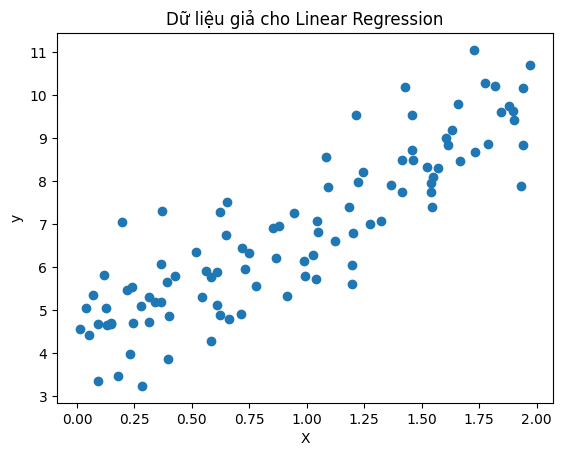

In [3]:
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Dữ liệu giả cho Linear Regression')
plt.show()

## 8. Khởi tạo tham số

Ban đầu model chưa biết đường thẳng tốt nhất là gì, nên ta khởi tạo `w` và `b` ngẫu nhiên.


In [4]:
w = np.random.randn(1, 1)
b = np.random.randn(1)

learning_rate = 0.1
epochs = 100
n = len(X)

loss_history = []

print('w ban đầu:', w)
print('b ban đầu:', b)

w ban đầu: [[0.01300189]]
b ban đầu: [1.45353408]


## 9. Huấn luyện Linear Regression bằng Gradient Descent

Quy trình mỗi epoch:

1. Model dự đoán `y_pred`
2. Tính loss MSE
3. Lưu loss vào `loss_history`
4. Tính gradient của `w` và `b`
5. Cập nhật `w` và `b`


In [5]:
for epoch in range(epochs):
    # 1. Dự đoán
    y_pred = X.dot(w) + b

    # 2. Tính loss MSE
    loss = np.mean((y - y_pred) ** 2)

    # 3. Lưu loss
    loss_history.append(loss)

    # 4. Tính gradient
    dw = (-2 / n) * X.T.dot(y - y_pred)
    db = (-2 / n) * np.sum(y - y_pred)

    # 5. Cập nhật tham số
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # In loss mỗi 10 epoch
    if epoch % 10 == 0:
        print(f'Epoch {epoch}: Loss = {loss:.4f}')

print('\nKết quả sau khi train:')
print('w sau khi train:', w)
print('b sau khi train:', b)

Epoch 0: Loss = 32.1386
Epoch 10: Loss = 0.8124
Epoch 20: Loss = 0.8091
Epoch 30: Loss = 0.8079
Epoch 40: Loss = 0.8072
Epoch 50: Loss = 0.8069
Epoch 60: Loss = 0.8067
Epoch 70: Loss = 0.8067
Epoch 80: Loss = 0.8066
Epoch 90: Loss = 0.8066

Kết quả sau khi train:
w sau khi train: [[2.77525035]]
b sau khi train: [4.20927818]


## 10. Vẽ biểu đồ Loss theo từng Epoch

Nếu Gradient Descent chạy đúng, biểu đồ loss thường sẽ giảm dần.


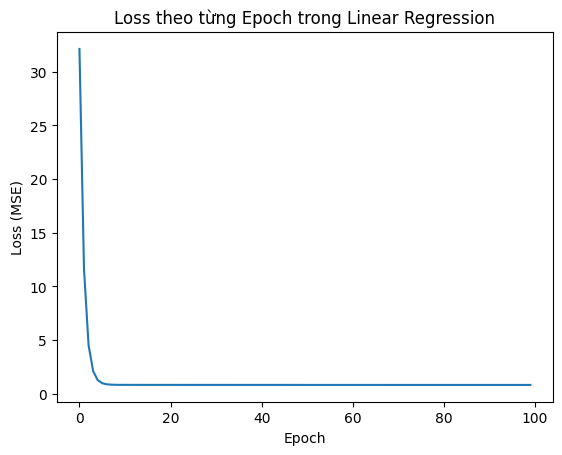

In [6]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss theo từng Epoch trong Linear Regression')
plt.show()

## 11. Vẽ đường dự đoán sau khi train

Ta vẽ đường thẳng mà model học được để xem nó có khớp với dữ liệu không.


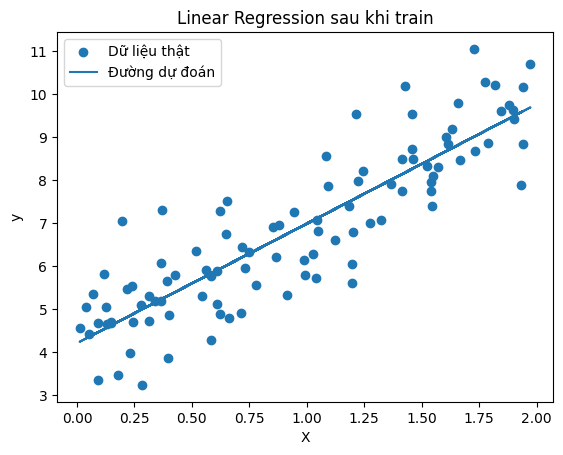

In [7]:
y_pred_final = X.dot(w) + b

plt.scatter(X, y, label='Dữ liệu thật')
plt.plot(X, y_pred_final, label='Đường dự đoán')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression sau khi train')
plt.legend()
plt.show()

## 12. Giải thích kết quả

Nếu biểu đồ loss giảm dần, nghĩa là:

- Model đang học đúng hướng
- Gradient Descent đang hoạt động
- `w` và `b` đang tiến gần đến giá trị tốt hơn

Nếu loss không giảm hoặc tăng mạnh, có thể do:

- Learning rate quá lớn
- Code tính gradient sai
- Dữ liệu có vấn đề

Nếu loss giảm quá chậm, có thể do:

- Learning rate quá nhỏ
- Epoch quá ít


## 13. Bài tập tự luyện

Hãy thử thay đổi các giá trị sau và quan sát biểu đồ loss:

### Bài 1

Đổi:

```python
learning_rate = 0.01
```

Quan sát loss giảm nhanh hay chậm.

### Bài 2

Đổi:

```python
learning_rate = 1
```

Quan sát xem loss có bị nhảy mạnh không.

### Bài 3

Đổi:

```python
epochs = 1000
```

Quan sát loss có tiếp tục giảm không.

### Bài 4

Tự viết lại toàn bộ vòng lặp Gradient Descent mà không nhìn code mẫu.


## 14. Kết luận

Trong Linear Regression bằng Gradient Descent, quy trình học là:

```text
Dự đoán → Tính loss → Tính gradient → Cập nhật w, b → Lặp lại
```

Biểu đồ loss theo epoch là cách đơn giản nhất để kiểm tra model có đang học hay không.

Đây là nền tảng rất quan trọng trước khi học các model phức tạp hơn như Logistic Regression, Neural Network và Deep Learning.
